# Gravedad Aparente
Calcula la magnitud de la gravedad aparente y el ángulo con la gravedad real
para una latitud dada, y muestra el diagrama vectorial sobre la esfera terrestre.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Arc, Ellipse, Circle


# aceleración gravedad real en m s^-1  
G_REAL = 9.80665    

# velocidad angular de la Tierra en rad s^-1  
OMEGA = 7.2921150e-5   

# radio medio de la Tierra en m
R = 6.371e6        

In [3]:
# Ingresa la latitud en grados [0–90]
lat = 19

In [4]:
phi = np.radians(lat)

# magnitud de la fuerza centrífuga
a_c = (OMEGA**2)*R*np.cos(phi)      

# Para hacer la suma vectorial haremos un cambio en lo que hicimos en clase.
# Vamos a poner unos ejes con el eje vertical alineado con la gravedad real.
# De esta forma, la fuerza centrífuga tiene dos componentes. Una radial que
# reduce la g y una tangencial que es la responsable de desviar la vertical.
g_ap  = np.sqrt((G_REAL-a_c*np.cos(phi))**2 + (a_c * np.sin(phi))**2)


alpha = np.degrees(np.arctan2(a_c*np.sin(phi), G_REAL-a_c*np.cos(phi)))
print(f"\n  g_ap = {g_ap:.5f} m/s²")
print(f"  α    = {alpha:.5f}°")


  g_ap = 9.77637 m/s²
  α    = 0.06112°


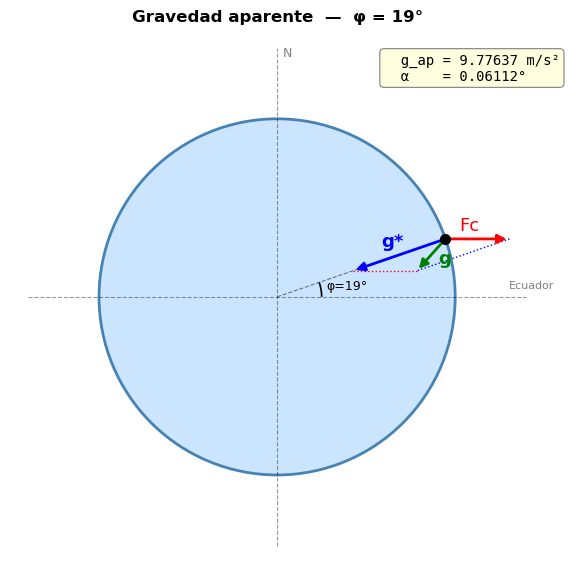

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axis("off")

# Tierra
ax.add_patch(Circle((0, 0), 1, facecolor="#cce5ff", edgecolor="steelblue", lw=2))

# Eje de rotación y Ecuador
ax.plot([0, 0], [-1.4, 1.4], "k--", lw=0.8, alpha=0.4)
ax.plot([-1.4, 1.4], [0, 0], "k--", lw=0.8, alpha=0.4)
ax.text(0.03,  1.35, "N", fontsize=9, color="gray")
ax.text(1.30,  0.05, "Ecuador", fontsize=8, color="gray")

# Punto en la superficie
px, py = np.cos(phi), np.sin(phi)
ax.plot(px, py, "ko", markersize=7, zorder=5)

# Arco de latitud
ax.add_patch(Arc((0, 0), 0.5, 0.5, angle=0, theta1=0, theta2=lat, color="black", lw=1.2))
ax.text(0.4*np.cos(phi/2), 0.4*np.sin(phi/2)-0.025, f"φ={lat}°", fontsize=9, color="black", ha="center")
ax.plot([0, px], [0, py], "k--", lw=0.8, alpha=0.5)

# Se van a dibujar unos vectores pero escalados.
# Escalas exagerada x 200 para que se vea
# Se define la longitud del vector G real. 
# como el circulo es unitario, entonces se escoge un valor <1.
VG  = 0.55
VAC = VG * (a_c / G_REAL) * 200

# g apunta al centro
dg  = np.array([-np.cos(phi), -np.sin(phi)])   

# centrífuga apunta hacia afuera
dac = np.array([1.0, 0.0])  

# suma vectorial
gap = dg*VG + dac*VAC                       

kw = dict(arrowstyle="-|>", mutation_scale=13, lw=2)
ax.annotate("", xy=(px + dg[0]*VG,  py + dg[1]*VG),  xytext=(px, py), arrowprops=dict(color="blue",  **kw))
ax.annotate("", xy=(px + dac[0]*VAC, py + dac[1]*VAC), xytext=(px, py), arrowprops=dict(color="red",   **kw))
ax.annotate("", xy=(px + gap[0],    py + gap[1]),    xytext=(px, py), arrowprops=dict(color="green", **kw))


# Paralelogramo punteado
g_tip   = np.array([px, py]) + dg  * VG
ac_tip  = np.array([px, py]) + dac * VAC
gap_tip = np.array([px, py]) + gap
ax.plot([g_tip[0], gap_tip[0]], [g_tip[1], gap_tip[1]], "r:", lw=1)
ax.plot([ac_tip[0], gap_tip[0]], [ac_tip[1], gap_tip[1]], "b:", lw=1)

# Etiquetas
ax.text(px + dg[0]*VG*0.5  - 0.10, py + dg[1]*VG*0.5+0.05,  "g*", color="blue",  fontsize=13, fontweight="bold")
ax.text(px + dac[0]*VAC*0.5-0.1, py + dac[1]*VAC*0.5 + 0.05, "Fc", color="red",   fontsize=13)
ax.text(px + gap[0]*0.5 + 0.04, py + gap[1]*0.5-0.05, "g", color="green", fontsize=13, fontweight="bold")


ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title(f"Gravedad aparente  —  φ = {lat}°", fontsize=12, fontweight="bold")


tabla = f"  g_ap = {g_ap:.5f} m/s²\n  α    = {alpha:.5f}°"
ax.text(0.7, 0.9, tabla, transform=ax.transAxes,
        fontsize=10, fontfamily="monospace", verticalalignment="bottom",
        bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray", lw=0.8))

plt.tight_layout()
plt.show()